# **Title : Burger's Equation**
$$ \frac {\partial u}{\partial t} + u\frac{\partial u}{\partial x} = \nu\frac{\partial^2 u}{\partial x^2}$$

# 1. Using FTCS scheme:
$$ u_i^{n+1} = u_i^n - \frac{\Delta t}{2\Delta x} u_i^n(u_{i+1}^n - u_{i-1}^n) + \frac{\nu \Delta t}{\Delta x^2}(u_{i+1}^n - 2 u_i^n + u_{i-1}^n) $$

Here, **Local Courant's number** is defined :
$$C_i^n = u_i^n\frac{\Delta t}{\Delta x}$$

Also, **Cell Diffusion Courant's number** is defined :
$$D = \frac{\nu \Delta t}{\Delta x^2}$$

Hence, equation becomes : 
$$u_i^n = (D + \frac {C_i^n}{2})u_{i-1}^n + (1 - 2D)u_i^n + (D - \frac {C_i^n}{2})u_{i+1}^n$$

Here, All coefficients must be positive. 
Hence 
$$(1 - 2D) > 0 \implies D<\frac{1}{2}$$


Also:
$$(D - \frac {C_i^n}{2}) \geqslant 0 \implies D \geqslant \frac {C_i^n}{2}$$
$$ 2 \geqslant \frac{u_i^n \Delta x}{\nu}$$
Which is defined as **Spatial Cell Packet Number(Pe)** :
$$Pe = \frac{u_i^n \Delta x}{\nu}$$

If Pe is less than 2 : Mesh is fine enough that diffusion can supresses sharp gradients

If Pe is greater than 2 : Convection overpowers diffusion causing wiggles at sharp gradients.

Both these conditions can be verified by Neumann Analysis as well.

The lower viscosity is applied, to satisfy this Pe condition, the smaller $\Delta x$ has to be used. Increasing the number of nodes and computational resources required.

This scheme is unconditionally unstable if we set viscosity as zero as the Pe will shoot to infinity. Physically, there is no diffusion availabe to counter the convection. Mathematically, for centred difference first order spatial derivative, a negative third order spatial derivative will be induced on the RHS. Such derivative forces the wave components of original wave to travel at speeds proportional to their wavelengths. This causes the wave to shred into component waves moving ahead and back with different velocities.

To solve this, upwind scheme is used to calculate the convection term.

dt = nu*dx is used to keep both these terms in check and between the criterias.

# Upwind Fix :

$$\frac{u_i - u_{i-1}}{\Delta x} = \left. \frac{\partial u}{\partial x} \right|_i - \mathbf{\frac{\Delta x}{2} \frac{\partial^2 u}{\partial x^2}} + \mathcal{O}(\Delta x^2)$$

This scheme, introduces an artificial viscosity component by itself. Even if we set the viscosity to zero, this viscosity component supresses the dispersion errors.

Also, the Pe criteria is completely eliminated. As the denominator of Pe now also contains this diffusion coefficient added along with the viscosity. Even if we set viscosity to zero, Pe = 2. 

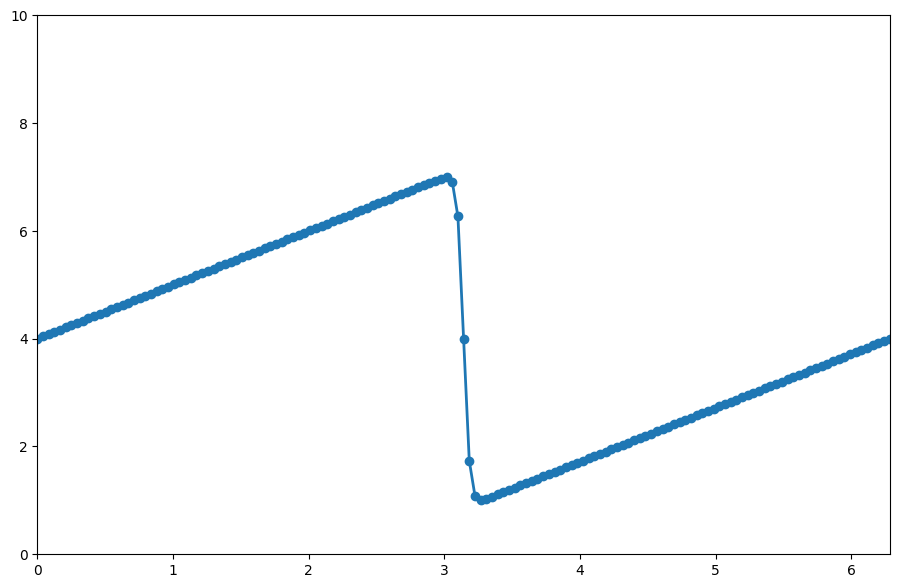

In [10]:
import numpy
import sympy
from sympy import init_printing
from sympy.utilities.lambdify import lambdify
init_printing(use_latex=True)
from matplotlib import pyplot
import time,sys
%matplotlib inline
x, nu, t = sympy.symbols('x nu t')
phi = (sympy.exp(-(x - 4 * t)**2 / (4 * nu * (t + 1))) +
       sympy.exp(-(x - 4 * t - 2 * sympy.pi)**2 / (4 * nu * (t + 1))))
phiprime = phi.diff(x)
u = -2 * nu * (phiprime / phi) + 4
ufunc = lambdify((t, x, nu), u)
nx = 151
nt = 140
dx = 2 * numpy.pi / (nx - 1)
nu = 0.07
dt = dx * nu

x = numpy.linspace(0, 2 * numpy.pi, nx)
un = numpy.empty(nx)
t = 0

u = numpy.asarray([ufunc(t, x0, nu) for x0 in x])
uorginal = u.copy()
pyplot.figure(figsize=(11, 7), dpi=100)
pyplot.plot(x, u, marker='o', lw=2)
pyplot.xlim([0, 2 * numpy.pi])
pyplot.ylim([0, 10]);


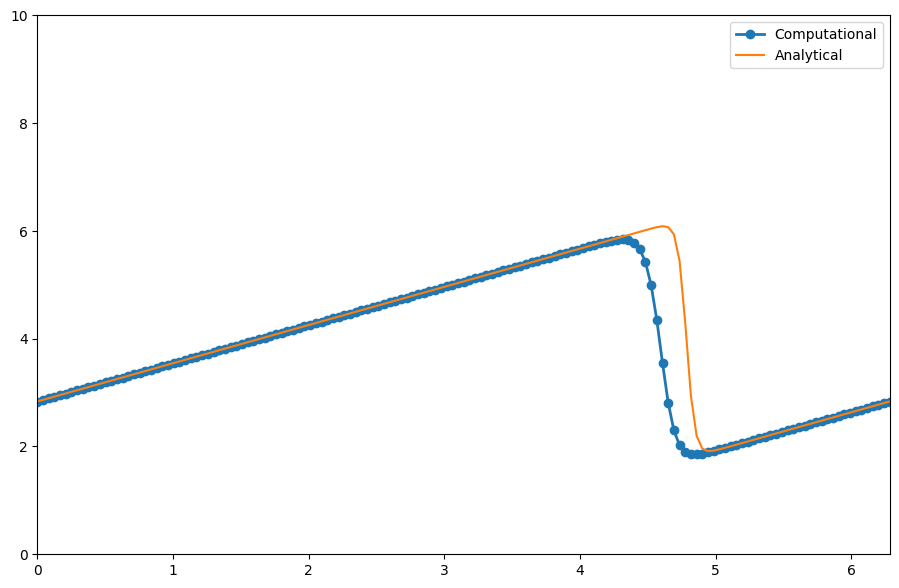

In [11]:
for n in range(nt):
    un = u.copy()
    for i in range(1, nx-1):
        u[i] = un[i] - un[i] * dt / dx *(un[i] - un[i-1]) + nu * dt / dx**2 *\
                (un[i+1] - 2 * un[i] + un[i-1])
    u[0] = un[0] - un[0] * dt / dx * (un[0] - un[-2]) + nu * dt / dx**2 *\
                (un[1] - 2 * un[0] + un[-2])
    u[-1] = u[0]
        
u_analytical = numpy.asarray([ufunc(nt * dt, xi, nu) for xi in x])
pyplot.figure(figsize=(11, 7), dpi=100)
pyplot.plot(x,u, marker='o', lw=2, label='Computational')
pyplot.plot(x, u_analytical, label='Analytical')
pyplot.xlim([0, 2 * numpy.pi])
pyplot.ylim([0, 10])
pyplot.legend();

# Crank Nicolson Scheme : 
 

For time domain, we discretize around some phantom point n + 1/2.

$$\frac{\partial u}{\partial t} = \frac{u^{n+1} - u^n}{\Delta t} - \frac{\Delta t^2}{24}\frac{\partial^3 u}{\partial t^3}

Also, we have to transform the spatial gradients to be evaluated at point n + 1/2. We use linear interpolation. Taking average of (n+1) and (n) states to predict spatial values at (n+1/2)

$$u\frac{\partial u}{\partial x} = \frac{1}{2}[u^{n+1}(\frac{u_{i+1}^{n+1} - u_{i-1}^{n+1}}{2\Delta x}) + u^n(\frac{u_{i+1}^n - u_{i-1}^n}{2\Delta x})]$$
Also :

$$ \nu \frac{\partial^2 u}{\partial x^2} = \frac{\nu}{2}[\frac{u_{i+1}^{n+1}-2u_i^{n+1}+u_{i-1}^{n+1}}{\Delta x^2} + \frac{u_{i+1}^n - 2u_i^n + u_{i-1}^n}{\Delta x^2}]$$

The final equation becomes : 
$$(1+D)u_i^{n+1} + (\frac{C_i^{n+1}}{4} - \frac{D}{2})u_{i+1}^{n+1} + (-\frac{C_i^{n+1}}{4} - \frac{D}{2})u_{i-1}^{n+1} = (1-D)u_i^n + (-\frac{C_i^n}{4} + \frac{D}{2})u_{i+1}^n + (\frac{C_i^n}{4} + \frac{D}{2})u_{i-1}^n$$

We can write it in matrix form as : 
$$Au^{n+1} = Bu^n$$

Here the equation seems linear and one can think of using Thomas Algorithm like methods to solve.

But, here the Matrix A contains Courant's Number terms. Here, the courant's number depends on the local velocity u at n+1. Making the LHS non linear, which cannot be solved by linear methods

Crank Nicolson is unconditionally stable. But it does not guarantee monotonicity. For whatever timestep you choose, the code will not blow up to extreme values, it will be stable. Especially when considering sharp gradients, the crank nicolson can generate wiggles instead of a smooth monotone decay.

Von neumann analysis gives us : 
$$G = \frac{1 - 2Dsin^2(\theta /2) - i\frac{C_j^n}{2}sin(\theta)}{1 + 2Dsin^2(\theta /2) + i\frac{C_j^{n+1}}{2}sin(\theta)}$$

where 
$i = \sqrt-1$

j - spatial grid points

$\theta = k\Delta x$

For extreme scenraio, $wavelength(\lambda) = 2\Delta x \implies k\Delta x = \theta = \pi$

Equation simplifies to : 
$$G = \frac{1 - 2D}{1 + 2D}$$

If timestep is large enough to make D > 0.5, G will be negative. But since the denominator is 1 + 2D, G will not shoot up to unreal huge values. But because of the negative sign, there will wiggles formed. 

# Picard's Iteration : 


Here a value is guessed initially. The equation is solved for that value which is the first iteration. The best obtained value from this iteration is used to again the solve the equation for the next iteration. This is repeated until the guessed value fits some pre decided tolerance.

The diagonal formed for this equation will be a tridiagonal matrix of which most of the enteries will be zeros. Hence instead of storing the entire matrix, only three diagonals will be stored in a banded matrix.

\begin{bmatrix}
(1+D) & \frac{c}{4}-\frac{D}{2} & 0 & \cdots & 0 \\
-\frac{c}{4}-\frac{D}{2} & (1+D) & \frac{c}{4}-\frac{D}{2} & \cdots & 0 \\
\vdots & \vdots & \ddots & \vdots & \vdots \\
0 & 0 & \cdots & -\frac{c}{4}-\frac{D}{2} & (1+D)
\end{bmatrix}


Banded Matrix of 3 columns and n rows will be formed. 

0th column - Upper Diagonal - (C/4 - D/2)

1st Column - Main Diagonal - (1 + D)

3rd Column - Lower Diagonal - (-C/4 - D/2)

solve_banded function from scipy will be used to solve the matrix.

This function when solving for ith row of the banded matrix, 

-> It will consider the ith element of main diagonal i.e 1st Column

-> It will consider the (i+1)th element of upper diagonal i.e 0th column

-> It will consider the (i-1)th element of lower diagonal i.e 2nd column

If applying Dirichlet boundary conditions, we have to hard code the first and last rows according to the conditions

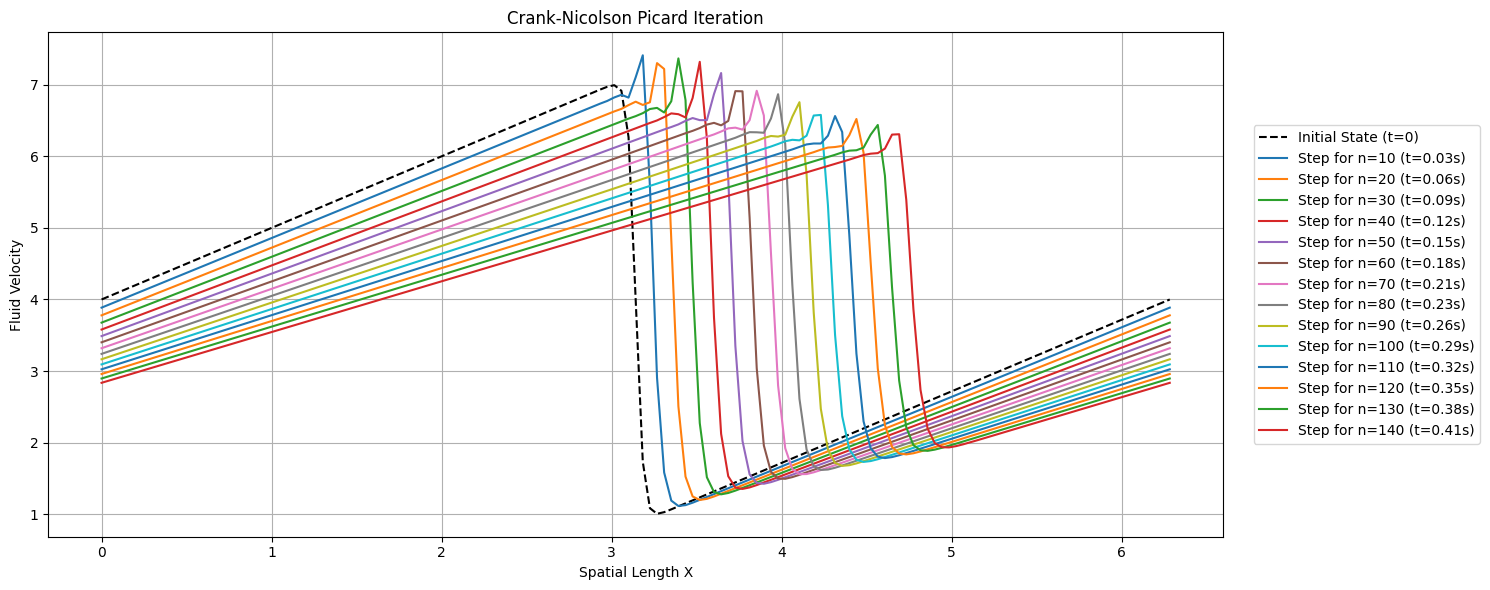

In [12]:
import numpy as np
from scipy.sparse import diags
from scipy.sparse.linalg import spsolve
from scipy.linalg import solve_banded
import matplotlib.pyplot as plt

L = 2*np.pi
nx = 151
dx = L/(nx - 1)
nt = 140
nu = 0.07
dt = dx*nu
D = nu*dt/dx**2
x = np.linspace(0,L,nx)
max_piter = 100 #max iterations allowed
piter_toll = 1e-5 #tolerance 
u = uorginal.copy()
u_next = u.copy()
npts = nx - 1 
plt.figure(figsize=(15, 6))
plt.plot(x, u, 'k--', label="Initial State (t=0)")
for n in range(nt): #looping through the timesteps
    
    b = np.zeros(npts) 
    for i in range (npts): #looping through each grid point and defining the RHS side matrix for 'n' timestep
        
        c_n = u[i]*dt/dx #local courant's number
        b[i] = (1-D)*u[i] + (D/2 - c_n/4)*u[(i+1)%npts] + (D/2 + c_n/4)*u[(i-1)%npts] # % operator is used to apply periodicity 
    u_k = u[:-1].copy() #initial guess
    cnvgd = False
    for k in range(max_piter): #loop for iterations
        main_diag = np.ones(nx)*(1 + D)
        upper_diag = np.ones(nx)
        lower_diag = np.ones(nx)
        for i in range(npts): #looping through each point to define the lower and upper diagonals for the matrix
            c_k = u_k[i]*dt/dx #local Courant's number for n+1 time
            if i < (npts - 1):
                upper_diag[i] = -D/2 + c_k/4
            if i > 0:
                lower_diag[i-1] = -D/2 - c_k/4
        Amat = diags([lower_diag, main_diag, upper_diag], [-1, 0, 1], shape=(npts,npts)).tolil()
        c_kfir = u_k[0]*dt/dx #applying boundary conditions
        Amat[0, -1] = -c_kfir/4 - D/2 
        c_klas = u_k[-1]*dt/dx
        Amat[-1, 0] = c_klas/4 - D/2
        Amat = Amat.tocsr()
        u_kf = spsolve(Amat,b) #solving the matrix
        iter_res = np.max(np.abs(u_kf - u_k)) #finding the difference in values
        if (iter_res < piter_toll):
            u_next = u_kf.copy()
            cnvgd = True
            break
        u_k = u_kf.copy()
    if not cnvgd :
        print('Warning! Code did not converge')
        u_next = u_k.copy()
    u[:-1] = u_k
    u[-1] = u[0]
    if (n + 1)%10 == 0 :
        plt.plot(x, u, label=f"Step for n={n+1} (t={(n+1)*dt:.2f}s)")
plt.title("Crank-Nicolson Picard Iteration")
plt.xlabel("Spatial Length X")
plt.ylabel("Fluid Velocity")
plt.grid(True)
plt.legend(
    loc='center left',
    bbox_to_anchor=(1.02, 0.5)
)
plt.tight_layout()
plt.show()

Here, the left side of the wave, before the drop seems to be flattening with time. The peak is moving at comparatively higher velocities than the points behind it. As time passes, the distance between these points keep growing, causing the slope to flatten and the wave expands. This is called expansion wave or rarefaction fan.

The peak seems to be getting shorter with time. This happens as the viscosity drains energy causing the wave to slow down. The velocity drop also gets gentler with time due to viscosity as it smoothens sharp gradients.

The sudden peak formation is see due to violation of picard's number criteria. For this nx, length and nu Pe = 4.16. As discussed earlier, the convection overpowers diffusion causing wiggles.

Picard treats one of the non linearity as a temporary constant based on the last guess. It doesn't measure how the function changes through space. Hence it, stalls for huge shocks or steep gradients. 

To overcome this, Newton Raphson Jacobian engine is used.

# Newton Raphson Jacobian Engine :

Consider a non linear function R(u) = 0

We guess initially, u = $u_k$

But, $R(u_k)\ne 0$

We calculate an adjustment $\Delta u$ such that $R(u_k + \Delta u) = 0$

Taylor series expansion yields : $\frac{d R(u_k)}{du} \Delta u = -R(u_k)$

We convert this into matrix form :

$$
\begin{bmatrix}
\frac{\partial R_1}{\partial u_1} & \frac{\partial R_1}{\partial u_2} & \frac{\partial R_1}{\partial u_3} & \cdots & \frac{\partial R_1}{\partial u_n}\\
\frac{\partial R_2}{\partial u_1} & \frac{\partial R_2}{\partial u_2} & \frac{\partial R_2}{\partial u_3} & \cdots & \frac{\partial R_2}{\partial u_n}\\
\frac{\partial R_3}{\partial u_1} & \frac{\partial R_3}{\partial u_2} & \frac{\partial R_3}{\partial u_3} & \cdots & \frac{\partial R_3}{\partial u_n}\\
\vdots & \vdots & \vdots & \ddots & \vdots\\
\frac{\partial R_n}{\partial u_1} & \frac{\partial R_n}{\partial u_2} & \frac{\partial R_n}{\partial u_3} & \cdots & \frac{\partial R_n}{\partial u_n}
\end{bmatrix}
\qquad
\begin{bmatrix}
\Delta u_1\\
\Delta u_2\\
\Delta u_3\\
\vdots\\
\Delta u_n
\end{bmatrix}
= -
\begin{bmatrix}
R_1\\
R_2\\
R_3\\
\vdots\\
R_n
\end{bmatrix}
$$

But every node is affected by just its neighbors. Hence this matrix will transform into a tridiagonal matrix.

In the crank nicolson scheme, if we correctly guess the values of n+1 timestep, then both sides will balance out and reduce to zero. For incorrect guess, there will be some residue left. We define a residual function R for a guess k.

$$R_i = u_i^{k} - u_i^n + \frac{\Delta t}{4\Delta x}u_i^{k}(u_{i+1}^{k} - u_{i-1}^{k}) + \frac{\Delta t}{4\Delta x}u_i^n(u_{i+1}^n - u_{i-1}^n) - \frac{D}{2}(u_{i+1}^{k} -2u_i^{k} + u_{i-1}^{k}) - \frac{D}{2}(u_{i+1}^{n} -2u_i^{n} + u_{i-1}^{n})$$

defining $a_c = \frac{\Delta t}{4\Delta x}$

$$\frac{\partial R_i}{\partial u_i^k} = 1 + a_c(u_{i+1}^k - u_{i-1}^k) + D$$

$$\frac{\partial R_i}{\partial u_{i+1}^k} = a_c u_i^k - D/2$$

$$\frac{\partial R_i}{\partial u_{i-1}^k} = -a_c u_i^k - D/2$$

According to Dirichlet boundary conditions :

$$R_0 = u_0^k - u_L$$
$$\frac{\partial R_0}{\partial u_0} = 1$$
$$\frac{\partial R_0}{\partial u_1} = 0$$

$$R_n = u_n^k - u_R$$
$$\frac{\partial R_n}{\partial u_n} = 1$$
$$\frac{\partial R_n}{\partial u_{n-1}} = 0$$

We again define a banded matrix with for the three diagonals. And iterate through the loop till the Residue fits some pre decided tolerance

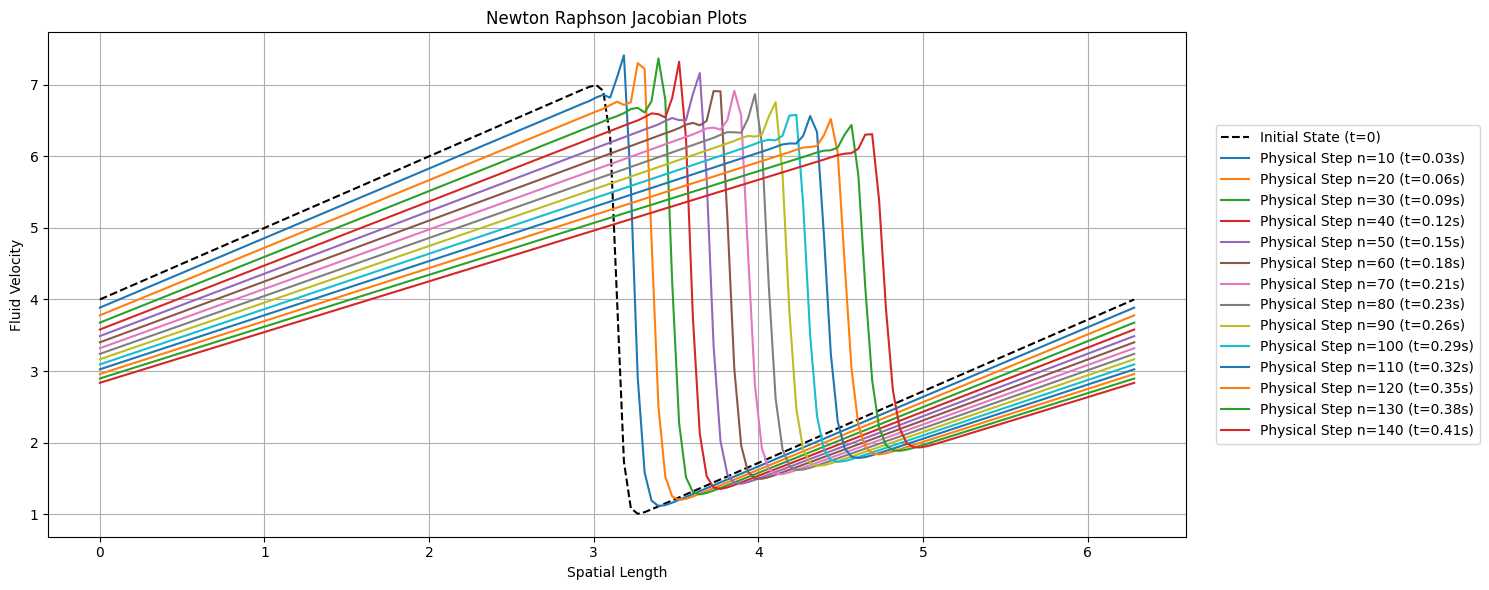

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import solve_banded
from scipy.sparse import diags
from scipy.sparse.linalg import spsolve


L = 2*np.pi
dx = L/(nx - 1)
nt = 140
#dt = 0.02
dt = nu*dx
nu = 0.07
nx = 151
D = nu*dt/dx**2
x = np.linspace(0,L,nx)
max_nriter = 100 #Maximum Iterations
nr_toll = 1e-5 #tolerance
npts = nx - 1
u = uorginal.copy()
u_next = u.copy()
plt.figure(figsize=(15, 6))
plt.plot(x, u, 'k--', label="Initial State (t=0)")
u_k = u[:-1].copy()
for n in range(nt): #looping through timesteps
    cnvgd = False
    for k in range(max_nriter): #looping through iterations
        r = np.zeros(npts)
        ac = dt/(4*dx)
        main_diag = np.ones(npts)
        upper_diag = np.ones(npts)
        lower_diag = np.ones(npts)

        for i in range(npts):
            r[i] = u_k[i] - u[i] + ac*u_k[i]*(u_k[(i+1)%npts] - u_k[(i-1)%npts]) + ac*u[i]*(u[(i+1)%npts] - u[(i-1)%npts]) - D/2*(u_k[(i+1)%npts] - 2*u_k[i] + u_k[(i-1)%npts]) - D/2*(u[(i+1)%npts] - 2*u[i] + u[(i-1)%npts])
            upper_diag[(i+1)%npts] = -D/2 + ac*u_k[i]
            lower_diag[(i-1)%npts] = -D/2 - ac*u_k[i]
            main_diag[i] = 1 + ac*(u_k[(i+1)%npts] - u_k[(i-1)%npts]) + D

        Amat = diags([lower_diag, main_diag, upper_diag],[-1,0,1],shape=(npts,npts)).tocsr()
        delta_u = spsolve( Amat, -r)
        u_k+= delta_u #adding calculated difference to original guess
        iter_res = np.max(np.abs(delta_u)) #checking the maximum difference
        if (iter_res < nr_toll):
            u_next = u_k.copy()
            cnvgd = True
            break
    if not cnvgd :
        print('Warning, values did not converge')
        u_next = u_k.copy()
    u[:-1] = u_next.copy()
    u[-1] = u[0]
    
    #if ((n + 1)%10 == 0) and (n>450): use this to see vicsous dissipation by increasing nt = 500
    if ((n + 1)%10 == 0):
        plt.plot(x, u, label=f"Physical Step n={n+1} (t={(n+1)*dt:.2f}s)")
plt.title("Newton Raphson Jacobian Plots")
plt.xlabel("Spatial Length")
plt.ylabel("Fluid Velocity")
plt.grid(True)
plt.legend(
    loc='center left',
    bbox_to_anchor=(1.02, 0.5)
)
plt.tight_layout()
plt.show()


Only one off shoot is seen for smaller value of dt. But as we increase dt value higher, multiple wiggles are seen. When dt is small dispersion is low, the code loops comparatively more times for same distance dampening these wiggles further. When dt is raised, dispersion increases. It allows the earlier supressed waves to seperate from the main wave.

Also, the more we increase nt, the more gentler, flatter the profile becomes. Viscosity dampens all the gradients. Causing the whole fluid to travel at a constant velocity dissipating kinectic energy to heat. 

# Conservative form of convection :

The convection component of the equation can be expressed in two forms :

Non Conservative form : $u\frac{\partial u}{\partial x}$ 

Conservative form : $\frac{1}{2}\frac{\partial u^2}{\partial x}$ 

The conservative form is preferred as it measures the flux across boundaries of the grid cells. 

Redefining residual function for the conservative form : 

$$R_i = u_i^{k} - u_i^n + \frac{\Delta t}{8\Delta x}((u_{i+1}^{k})^2 - (u_{i-1}^{k})^2) + \frac{\Delta t}{8\Delta x}((u_{i+1}^n)^2 - (u_{i-1}^n)^2) - \frac{D}{2}(u_{i+1}^{k} -2u_i^{k} + u_{i-1}^{k}) - \frac{D}{2}(u_{i+1}^{n} -2u_i^{n} + u_{i-1}^{n})$$

Defining $\beta = \frac{\Delta t}{8\Delta x}$

$$\frac{\partial R_i}{\partial u_i^k} = 1 + D$$

$$\frac{\partial R_i}{\partial u_{i+1}^k} = 2 \beta u_{i+1}^k - D/2$$

$$\frac{\partial R_i}{\partial u_{i-1}^k} = -2 \beta u_{i+1}^k - D/2$$

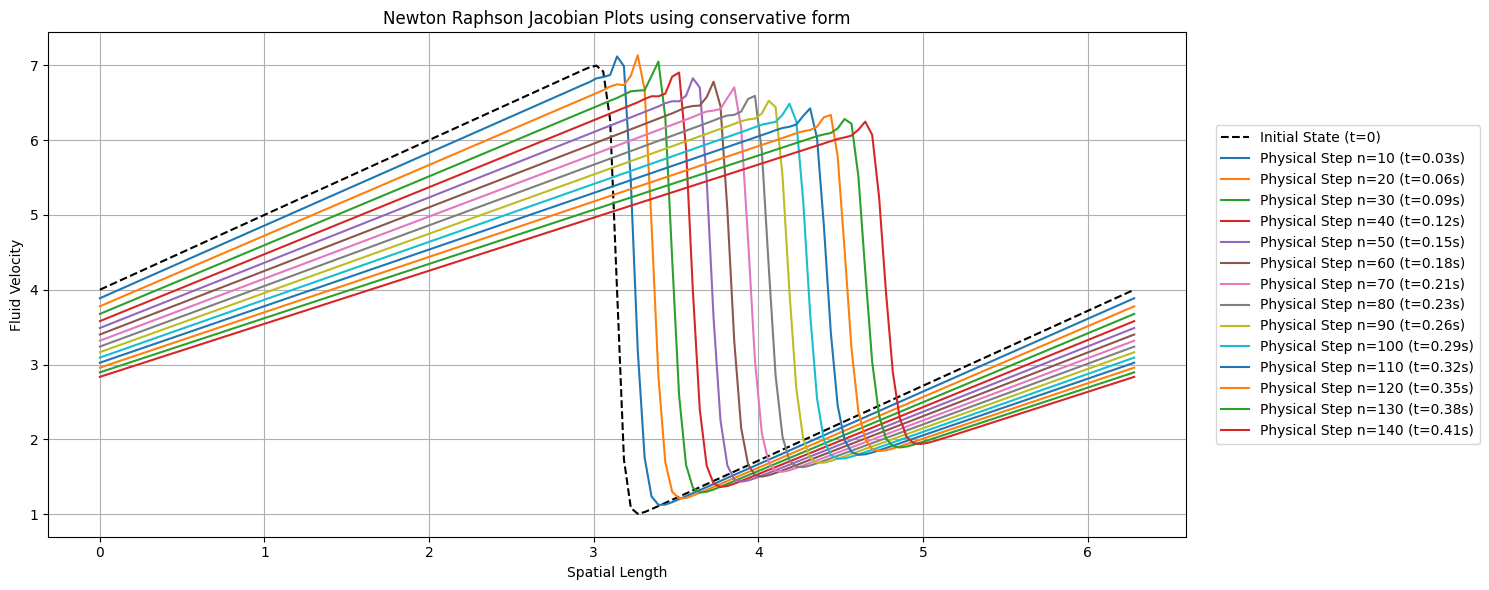

In [14]:

import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import solve_banded
from scipy.sparse import diags
from scipy.sparse.linalg import spsolve


L = 2*np.pi
dx = L/(nx - 1)
nt = 140
#dt = 0.02
dt = nu*dx
nu = 0.07
nx = 151
D = nu*dt/dx**2
x = np.linspace(0,L,nx)
max_nriter = 100 #Maximum Iterations
nr_toll = 1e-5 #tolerance
npts = nx - 1
u = uorginal.copy()
u_next = u.copy()
plt.figure(figsize=(15, 6))
plt.plot(x, u, 'k--', label="Initial State (t=0)")
u_k = u[:-1].copy()
for n in range(nt): #looping through timesteps
    cnvgd = False
    for k in range(max_nriter): #looping through iterations
        r = np.zeros(npts)
        b = dt/(8*dx)
        main_diag = np.ones(npts)
        upper_diag = np.ones(npts)
        lower_diag = np.ones(npts)

        for i in range(npts):
            r[i] = u_k[i] - u[i] + b*(u_k[(i+1)%npts]**2 - u_k[(i-1)%npts]**2) + b*(u[(i+1)%npts]**2 - u[(i-1)%npts]**2) - D/2*(u_k[(i+1)%npts] - 2*u_k[i] + u_k[(i-1)%npts]) - D/2*(u[(i+1)%npts] - 2*u[i] + u[(i-1)%npts])
            upper_diag[(i+1)%npts] = -D/2 + 2*b*u_k[i]
            lower_diag[(i-1)%npts] = -D/2 - 2*b*u_k[i]
            main_diag[i] = 1 + D

        Amat = diags([lower_diag, main_diag, upper_diag],[-1,0,1],shape=(npts,npts)).tocsr()
        delta_u = spsolve( Amat, -r)
        u_k+= delta_u #adding calculated difference to original guess
        iter_res = np.max(np.abs(delta_u)) #checking the maximum difference
        if (iter_res < nr_toll):
            u_next = u_k.copy()
            cnvgd = True
            break
    if not cnvgd :
        print('Warning, values did not converge')
        u_next = u_k.copy()
    u[:-1] = u_next.copy()
    u[-1] = u[0]
    
    #if ((n + 1)%10 == 0) and (n>450): use this to see vicsous dissipation by increasing nt = 500
    if ((n + 1)%10 == 0):
        plt.plot(x, u, label=f"Physical Step n={n+1} (t={(n+1)*dt:.2f}s)")
plt.title("Newton Raphson Jacobian Plots using conservative form")
plt.xlabel("Spatial Length")
plt.ylabel("Fluid Velocity")
plt.grid(True)
plt.legend(
    loc='center left',
    bbox_to_anchor=(1.02, 0.5)
)
plt.tight_layout()
plt.show()




# Cole - Hopf Transformation :

If we consider $u = \frac{\partial \phi}{\partial x}$ and subsitute in original Burger's Equation, upon simplification we get :
$$\frac{\partial \phi}{\partial t} = \nu \frac{\partial^2 \phi}{\partial x^2}$$
This is the 1D Linear equation.
Using this transformation, we have eliminated our non linear component.

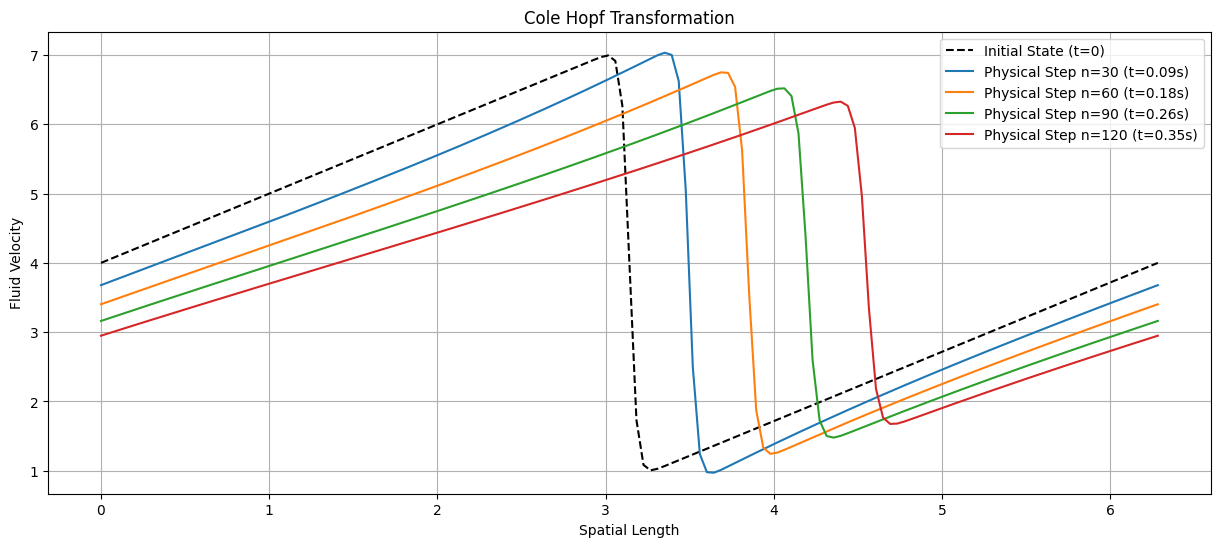

In [25]:
import numpy
import sympy
from sympy import init_printing
from sympy.utilities.lambdify import lambdify
init_printing(use_latex=True)
from matplotlib import pyplot
import time,sys
%matplotlib inline
x, nu, t = sympy.symbols('x nu t')
phi = (sympy.exp(-(x - 4 * t)**2 / (4 * nu * (t + 1))) +
       sympy.exp(-(x - 4 * t - 2 * sympy.pi)**2 / (4 * nu * (t + 1))))
phiprime = phi.diff(x)
u = -2 * nu * (phiprime / phi) + 4
ufunc = lambdify((t, x, nu), u)
xmin = 0
xmax = 2*np.pi
nx = 151
nt = 140
dx = (xmax - xmin)/(nx - 1)
nu = 0.07
dt = dx * nu
x = np.linspace(xmin, xmax, nx)
un = numpy.empty(nx)
t = 0
u_initial = numpy.asarray([ufunc(t, x0, nu) for x0 in x])
D = (nu*dt)/(dx**2)
plt.figure(figsize=(15, 6))
plt.plot(x, u_initial, 'k--', label="Initial State (t=0)")

npts = nx - 1 

for n in range(nt):

    tp = (n + 1) * dt


    phi = np.exp((-(x-4*tp)**2)/(4*nu*(tp+1))) + np.exp((-(x - 4*tp - 2*np.pi)**2)/(4*nu*(tp+1))) #defining the given phi function

    phi_in = phi[:-1].copy()

    b = np.zeros(npts)
    for i in range(npts):
        prevnode = phi_in[(i-1)%npts]
        nxtnode = phi_in[(i+1)%npts]
        cnode = phi_in[i]

        b[i] = (1 - D)*cnode + D*prevnode/2 + D*nxtnode/2

    main_diag = np.ones(npts)*(1 + D)
    sub_diag = np.ones(npts -1 )*(-D/2)
    Adiag = diags([sub_diag, main_diag, sub_diag],[-1,0,1], shape=(npts,npts)).tolil()
    Adiag[0,-1] = -D/2
    Adiag[-1,0] = -D/2
    Adiag = Adiag.tocsr()

    phi_nxt = spsolve(Adiag, b)
    phi_in = phi_nxt.copy()

    phifinal = np.zeros(nx)
    phifinal[:-1] = phi_in.copy()
    phifinal[-1] = phifinal[0]

    ucomp = np.zeros(nx)

    for i in range(nx):
        prevphi = phifinal[(i-1)%npts]
        nxtphi = phifinal[(i+1)%npts]

        gradphi = (nxtphi - prevphi)/(2*dx)
        ucomp[i] = -2*nu*gradphi/phifinal[i] + 4

    if (n + 1) % 30 == 0:
        t_c = (n + 1) * dt
        plt.plot(x, ucomp, label=f"Physical Step n={n+1} (t={t_c:.2f}s)")

plt.title("Cole Hopf Transformation")
plt.xlabel("Spatial Length")
plt.ylabel("Fluid Velocity")
plt.grid(True)
plt.legend()
plt.show()


